In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("../Data/data.xlsx")


print(df.shape)
df.info()
print((df.isna().mean() * 100).round(2))       
print("Duplicates:", df.duplicated().sum())
print("Cancellations:", df["InvoiceNo"].astype(str).str.startswith("C").sum())
print("Quantity <= 0:", (df["Quantity"] <= 0).sum())
print("UnitPrice <= 0:", (df["UnitPrice"] <= 0).sum())
print("Period:", df["InvoiceDate"].min(), "→", df["InvoiceDate"].max())
print(df.describe())
print(df[~df["StockCode"].astype(str).str.match(r"^\d{5}")]["StockCode"].value_counts().head(10))





(541909, 8)
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB
InvoiceNo       0.00
StockCode       0.00
Description     0.27
Quantity        0.00
InvoiceDate     0.00
UnitPrice       0.00
CustomerID     24.93
Country         0.00
dtype: float64
Duplicates: 5268
Cancellations: 9288
Quantity <= 0: 10624
UnitPrice <= 0: 2517
Period: 2010-12-01 08:26:00 → 2011-12

In [33]:
df = df.drop_duplicates()
df = df.dropna(subset=["CustomerID"])
df["CustomerID"] = df["CustomerID"].astype(int)
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]
df = df[df["StockCode"].astype(str).str.match(r"^\d{5}")]
print("After cleaning:", df.shape, "| customers:", df["CustomerID"].nunique())




After cleaning: (391150, 8) | customers: 4334


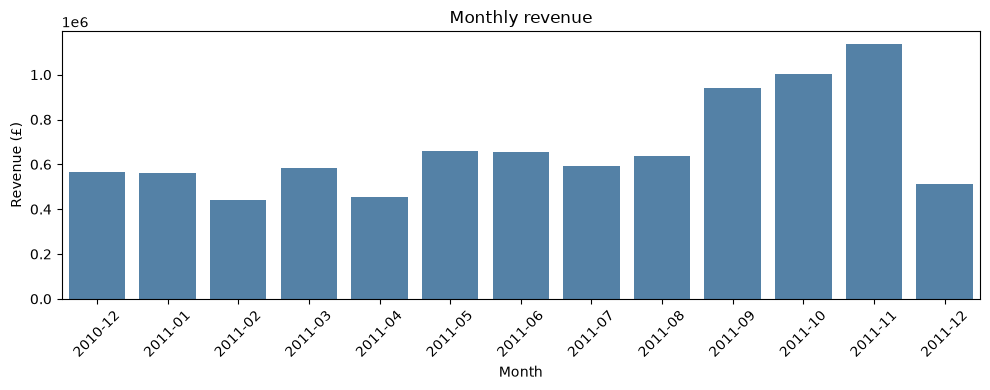

In [34]:
import matplotlib.pyplot as plt

df["Amount"] = df["Quantity"] * df["UnitPrice"]
df["Month"] = df["InvoiceDate"].dt.to_period("M")
monthly_revenue = df.groupby("Month")["Amount"].sum()
plt.figure(figsize=(10, 4))
sns.barplot(x=monthly_revenue.index.astype(str), y=monthly_revenue.values, color="steelblue")
plt.title("Monthly revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [35]:
df["Amount"] = df["Quantity"] * df["UnitPrice"]

now = df["InvoiceDate"].max() + pd.Timedelta(days=1)

frequency = df.groupby("CustomerID")["InvoiceNo"].nunique()
monetary  = df.groupby("CustomerID")["Amount"].sum().round(2)
recency   = (now - df.groupby("CustomerID")["InvoiceDate"].max()).dt.days

rfm = pd.concat([recency, frequency, monetary], axis=1)
rfm.columns = ["Recency", "Frequency", "Monetary"]
rfm = rfm.reset_index()
rfm.info()
print(rfm.describe())
print(rfm.head())

<class 'pandas.DataFrame'>
RangeIndex: 4334 entries, 0 to 4333
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  4334 non-null   int64  
 1   Recency     4334 non-null   int64  
 2   Frequency   4334 non-null   int64  
 3   Monetary    4334 non-null   float64
dtypes: float64(1), int64(3)
memory usage: 135.6 KB
         CustomerID      Recency    Frequency       Monetary
count   4334.000000  4334.000000  4334.000000    4334.000000
mean   15299.251731    92.703046     4.245962    2015.973152
std     1721.994109   100.177047     7.634989    8903.673825
min    12346.000000     1.000000     1.000000       3.750000
25%    13812.250000    18.000000     1.000000     304.240000
50%    15297.500000    51.000000     2.000000     662.565000
75%    16778.750000   143.000000     5.000000    1631.622500
max    18287.000000   374.000000   206.000000  279138.020000
   CustomerID  Recency  Frequency  Monetary
0       12346 

In [36]:
import numpy as np
from sklearn.preprocessing import StandardScaler

rfm_log = np.log1p(rfm[['Recency', 'Frequency', 'Monetary']])
rfm_scaled = StandardScaler().fit_transform(rfm_log)

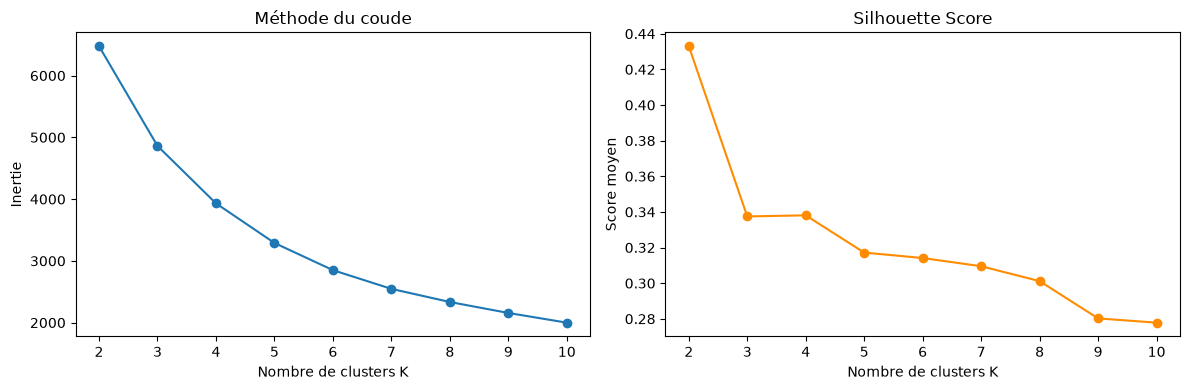

In [37]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 11)
inertias =[] 
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(rfm_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(rfm_scaled, labels))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(k_range, inertias, marker="o")
ax[0].set_title("Méthode du coude")
ax[0].set_xlabel("Nombre de clusters K")
ax[0].set_ylabel("Inertie")

ax[1].plot(k_range, silhouettes, marker="o", color="darkorange")
ax[1].set_title("Silhouette Score")
ax[1].set_xlabel("Nombre de clusters K")
ax[1].set_ylabel("Score moyen")

plt.tight_layout()
plt.show()

In [38]:
best_k = range(2,10)[silhouettes.index(max(silhouettes))]
best_k

2

In [39]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X = StandardScaler().fit_transform(rfm[["Recency", "Frequency", "Monetary"]])


kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X)


labels = kmeans.labels_



rfm["Cluster"] = labels

profil = rfm.groupby("Cluster").agg(
    Customers=("Recency", "count"),
    Recency_mean=("Recency", "mean"),
    Recency_median=("Recency", "median"),
    Frequency_mean=("Frequency", "mean"),
    Frequency_median=("Frequency", "median"),
    Monetary_mean=("Monetary", "mean"),
    Monetary_median=("Monetary", "median"),
    Monetary_sum=("Monetary", "sum"),
)
print(profil)

         Customers  Recency_mean  Recency_median  Frequency_mean  \
Cluster                                                            
0             3225     41.418295            30.0        4.651473   
1             1084    247.276753           242.5        1.572878   
2               25      6.120000             3.0       67.840000   

         Frequency_median  Monetary_mean  Monetary_median  Monetary_sum  
Cluster                                                                  
0                     3.0    1833.644577           903.90    5913503.76  
1                     1.0     624.748146           309.46     677226.99  
2                    54.0   85859.875600         58762.08    2146496.89  


In [40]:
profil = rfm.groupby("Cluster").agg(
    Clients=("Recency", "count"),
    Recency_moy=("Recency", "mean"),
    Frequency_moy=("Frequency", "mean"),
    Monetary_moy=("Monetary", "mean"),
    CA_total=("Monetary", "sum"),
)

profil

,Clients,Recency_moy,Frequency_moy,Monetary_moy,CA_total
Cluster,,,,,
0,3225,41.418295,4.651473,1833.644577,5913503.76
1,1084,247.276753,1.572878,624.748146,677226.99
2,25,6.120000,67.840000,85859.875600,2146496.89


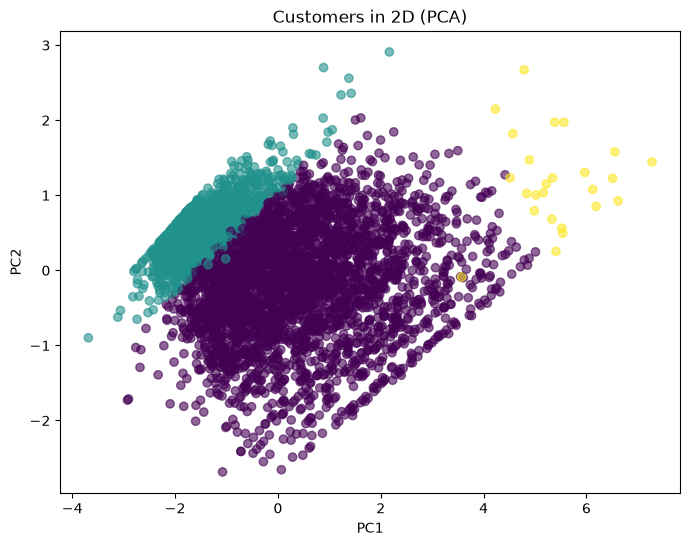

In [41]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(rfm_scaled)


prin_DF = pd.DataFrame(coords, columns=["PC1", "PC2"])
prin_DF["Cluster"] = rfm["Cluster"].values
plt.figure(figsize=(8, 6))
plt.scatter(prin_DF["PC1"], prin_DF["PC2"], c=prin_DF["Cluster"], cmap="viridis", alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customers in 2D (PCA)")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV


y =rfm["Cluster"]
X= rfm[["Recency", "Frequency", "Monetary"]]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


rf = RandomForestClassifier(random_state=42)

param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    rf,
    param_grid_rf,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)

# print("Best parameters:", rf_grid.best_params_)
best_rf = rf_grid.best_estimator_
y_pred = best_rf.predict(X_test)



print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9988465974625144
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       645
           1       1.00      1.00      1.00       217
           2       0.83      1.00      0.91         5

    accuracy                           1.00       867
   macro avg       0.94      1.00      0.97       867
weighted avg       1.00      1.00      1.00       867

[[644   0   1]
 [  0 217   0]
 [  0   0   5]]


In [43]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(best_rf.feature_importances_,
                        index=["Recency", "Frequency", "Monetary"]).sort_values(ascending=False)

print(importances.round(3))
print("Somme :", importances.sum())

Recency      0.856
Frequency    0.078
Monetary     0.066
dtype: float64
Somme : 1.0


In [44]:
import pandas as pd

nouveau_client = pd.DataFrame({
    "Recency": [15],      
    "Frequency": [12],    
    "Monetary": [3500]    
})
cluster_predit = best_rf.predict(nouveau_client)[0]

noms_segments= {
    0 : "Clients occasionnels",
    1 : "Client régulier",
    2 : "client fidele"
}

print(f"Cluster prédit : {cluster_predit}")
print(f"Segment        : {noms_segments[cluster_predit]}")
print(profil.loc[0])



Cluster prédit : 0
Segment        : Clients occasionnels
Clients          3.225000e+03
Recency_moy      4.141829e+01
Frequency_moy    4.651473e+00
Monetary_moy     1.833645e+03
CA_total         5.913504e+06
Name: 0, dtype: float64


In [45]:
import joblib

joblib.dump(best_rf, "modele_rf_segmentation.joblib")

['modele_rf_segmentation.joblib']

In [46]:
noms_segments= {
    0 : "Clients occasionnels",
    1 : "Client régulier",
    2 : "client fidele"
}
joblib.dump(noms_segments, "noms_segments.joblib")

['noms_segments.joblib']

In [47]:
import joblib
import pandas as pd

modele = joblib.load("modele_rf_segmentation.joblib")
noms_segments = joblib.load("noms_segments.joblib")

In [48]:


cluster = modele.predict(nouveau_client)[0]

print("Cluster prédit :", cluster)
print("Segment        :", noms_segments[cluster])
print(nouveau_client)

Cluster prédit : 0
Segment        : Clients occasionnels
   Recency  Frequency  Monetary
0       15         12      3500


In [49]:
modele = joblib.load("modele_rf_segmentation.joblib")

print(best_rf.predict(nouveau_client)[0] == modele.predict(nouveau_client)[0])

True
